In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# =====================================================
# STEP 1: Import Libraries
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay



# =====================================================
# STEP 3: Load Dataset
# =====================================================

path = "/content/drive/MyDrive/"     # Change if your files are inside a folder

X_train = pd.read_csv(path + "X_train.csv")
X_test = pd.read_csv(path + "X_test.csv")
y_train = pd.read_csv(path + "y_train.csv").squeeze()
y_test = pd.read_csv(path + "y_test.csv").squeeze()

# =====================================================
# STEP 4: Check Different Values of K
# =====================================================

k_values = [1,3,5,7,9,11,13,15]

print("Accuracy for Different K Values\n")

best_k = 1
best_accuracy = 0

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"K = {k}   Accuracy = {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print("\nBest K =", best_k)

Accuracy for Different K Values

K = 1   Accuracy = 0.9465
K = 3   Accuracy = 0.9549
K = 5   Accuracy = 0.9582
K = 7   Accuracy = 0.9580
K = 9   Accuracy = 0.9576
K = 11   Accuracy = 0.9582
K = 13   Accuracy = 0.9576
K = 15   Accuracy = 0.9578

Best K = 5



========== Evaluation Metrics ==========

Best K    : 5
Accuracy  : 0.9582
Precision : 0.783
Recall    : 0.3156
F1 Score  : 0.4499
ROC-AUC   : 0.8141

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4596
           1       0.78      0.32      0.45       263

    accuracy                           0.96      4859
   macro avg       0.87      0.66      0.71      4859
weighted avg       0.95      0.96      0.95      4859


Confusion Matrix

[[4573   23]
 [ 180   83]]


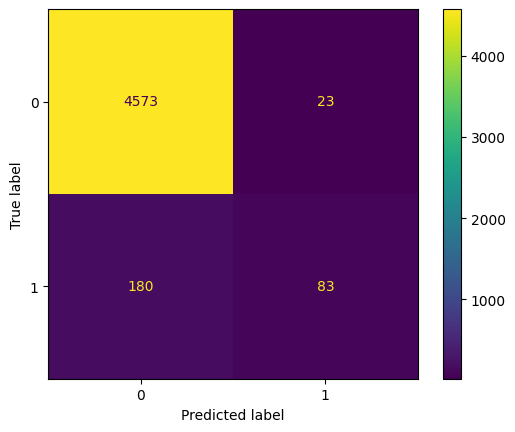

In [7]:
# =====================================================
# STEP 5: Train Final Model
# =====================================================

model = KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train, y_train)

# =====================================================
# STEP 6: Prediction
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# =====================================================
# STEP 7: Evaluation
# =====================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== Evaluation Metrics ==========\n")

print("Best K    :", best_k)
print("Accuracy  :", round(accuracy,4))
print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))
print("ROC-AUC   :", round(roc_auc,4))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix\n")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()